# Get Properties

Jupyter notbook interface for the automated collection of molecular descriptors and post-processing (i.e., Boltzmann average, min/max values, etc.) from Gaussian16 log files. Be sure to use the included environment before running.

__Contributors__
- Brittany C. Haas, PhD
- Melissa A. Hardy, PhD
- Jordan P. Liles, PhD
- James R. Howard, PhD

## Imports

In [ ]:
# stdlib
import os
import sys
import time
import shutil
import logging
import itertools

from pathlib import Path
from pprint import pprint
from multiprocessing import Pool

# Data wrangling
import numpy as np
import pandas as pd

# Jupyter
from IPython.display import SVG, display

# RDKit
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

# Custom
from utils import _get_atom_map, mol_to_image

from goodvibes_functions import get_goodvibes_data
from property_functions import get_frontierorbs, get_polarizability, get_dipole, get_volume
from property_functions import get_SASA, get_nbo, get_nmr, get_distance, get_angles, get_dihedral
from property_functions import get_vbur_scan, get_sterimol_morfeus, get_chelpg, get_hirshfeld
from property_functions import get_pyramidalization, get_wall_time, get_plane_angle

from utils import convert_files_in_directory
from utils import _read_in_mol_sdf_with_xyz_correction
from utils import FILE_COLUMN_NAME
from utils import draw_3D_mol
from utils import configure_logger

# Initial settings
pd.options.display.max_columns = None
randomstate = 42
logger = logging.getLogger('notebook')

[DEBUG - 03/13/2026:14:09:33] [__init__] matplotlib data path: /opt/miniconda3/envs/gpenv_312/lib/python3.12/site-packages/matplotlib/mpl-data
[DEBUG - 03/13/2026:14:09:33] [__init__] CONFIGDIR=/Users/jameshoward/.matplotlib
[DEBUG - 03/13/2026:14:09:33] [__init__] interactive is False
[DEBUG - 03/13/2026:14:09:33] [__init__] platform is darwin
[DEBUG - 03/13/2026:14:09:33] [__init__] CACHEDIR=/Users/jameshoward/.matplotlib
[DEBUG - 03/13/2026:14:09:33] [font_manager] Using fontManager instance from /Users/jameshoward/.matplotlib/fontlist-v390.json


## Settings
In this section, point the Path `data` to the directory containing your G16 log files. The script will automatically convert them to .mol files for further processing.

In [2]:
# Point to path of the log files
data_dir = Path('./data/test_files')

# Point to path where you want failed .log files to be moved
failed_dir = Path('./data/test_files_failed/')

# Point to path where results are saved
results_dir = Path('./results/')
results_dir.mkdir(exist_ok=True, parents=True)

# Define number of processors to use (set to number or os.cpu_count())
procs = os.cpu_count()

# Turn on debug printing
debug = True

# Format the logging (you don't have to edit this)
configure_logger(debug=debug)

## Convert .log files to .mol files
This section converts the .log files to .mol files. These .mol files can be read in with RDKit for 
downstream processing. Files that fail to convert will be moved to the `failed_dir`.

In [3]:
# Convert the logfiles into .mol files for reading in with RDKit
# This function returns the files that failed and will be moved
failed_files = convert_files_in_directory(directory=data_dir,
                                          failed_directory=failed_dir)

# Move and log the failed files
if len(failed_files) != 0:
    failed_dir.mkdir(exist_ok=True)
    logger.warning(f'Some files do not have corresponding .mol files')
    for f in failed_files:
        logger.warning(f.name)
        shutil.move(f, failed_dir / f.name)
        shutil.move(f.with_suffix('.log'), failed_dir / f.with_suffix('.log').name)

logger.info('There are %d files that do not have a corresponding .mol file.', len(failed_files))

[INFO  - 03/13/2026:14:09:33] [utils] Converting 0 logfiles to .mol files.
[INFO  - 03/13/2026:14:09:33] [4018218273] There are 0 files that do not have a corresponding .mol file.


## Define Substructure for Parameterization
Provide and [SMARTS](https://www.daylight.com/dayhtml/doc/theory/theory.smarts.html) string or SMILES string that defines the substructure to parameterize. If you are unfamiliar with defining SMARTS patterns, begin by copying the SMILES directly from ChemDraw first. If that does not correspond to your desired substructure (e.g., hydrogens are missing), consult the [SMARTS documentation](https://www.daylight.com/dayhtml/doc/theory/theory.smarts.html).


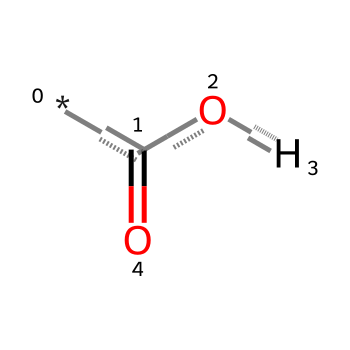

In [4]:
# Define a substructure common to all data files you are looking at
substructure = Chem.MolFromSmarts('[*]C(O[H])=O')

im = mol_to_image(substructure,
                  show_atom_indices=True,
                  image_size=(350, 350))

display(SVG(data=im))

## Generate DataFrame containing files and atom numbers
Here we read in the `.sdf` files and identify the substructure pattern in each. These identified patterns will be assigned an atom number (1-indexed values) that we will eventually turn into a text label that is meaningful for parameterization.

In [5]:
# Get the atom maps in parallel
with Pool(processes=procs) as p:
    results = p.starmap(_get_atom_map, zip(list(data_dir.glob('*.mol')), itertools.repeat(substructure)))

failed_files = []
new_results = []

# Iterate through the results
for item in results:
    if item[1] is None:
        logger.warning('%s is not readable with RDKit or had multiple substructure matches. .mol exists: %s', item[0].name, item[0].with_suffix(".mol").exists())
        failed_files.append(item[0])
    else:
        new_results.append(item)

# Place the atom numbers for the substructure for each log file into a dataframe
prelim_df = pd.DataFrame(new_results)
prelim_df.rename(columns={0: FILE_COLUMN_NAME}, inplace=True)

# Save the prelim dataframe
prelim_df.to_csv(results_dir / 'preliminary_df.csv')

# Print the failed items
if len(failed_files) != 0:
    failed_dir.mkdir(exist_ok=True)
    logger.warning('Files that were not read in with RDKit.')
    for f in failed_files:
        logger.warning(f.name)
        shutil.move(f, failed_dir / f.name)
        shutil.move(f.with_suffix('.log'), failed_dir / f.with_suffix('.log').name)

logger.info('There are %d files that were not read in.', len(failed_files))
logger.info('There are %d files that successfully read in.', prelim_df.shape[0])
display(prelim_df)

[INFO  - 03/13/2026:14:09:34] [1734846488] There are 0 files that were not read in.
[INFO  - 03/13/2026:14:09:34] [1734846488] There are 14 files that successfully read in.


,file,1,2,3,4,5
0,Ac5_1.log,3,2,12,24,1
1,Ac5_2.log,3,2,12,24,1
2,Ac5_3.log,3,2,12,24,1
3,Ac2_2.log,3,2,1,13,12
4,Ac4_4.log,3,2,1,12,11
5,Ac2_3.log,3,2,1,13,12
6,Ac2_1.log,3,2,1,13,12
7,Ac2_4.log,3,2,1,13,12
8,Ac4_2.log,3,2,1,12,11
9,Ac4_3.log,3,2,1,12,11


## Rename columns to user-interpretable labels

This cell will randomly sample rows in your `prelim_df` and draw the molecules with several atoms replaced with column headers (i.e., the atom numbers from your atom map). These column headers should be reassigned to a user-defined label that is more meaningful for property collection. The dictionary template printed at the end of this cell should look something like `{1: '', 2: '', 3: '', 4: '', 5: ''}`. This can be used in the next cell by remapping the numbers to text labels that are easier to understand.

```python
atom_labels = {1: 'C4', 
               2: 'C1', 
               3: 'O3', 
               4: 'H5', 
               5: 'O2'}
```

In [6]:
# Define the number of rows to sample
number_to_sample = 2

for i, row in prelim_df.iterrows():

    if i == number_to_sample:
        break

    # Read in the file as mol object
    file = Path(data_dir / row[FILE_COLUMN_NAME]).with_suffix('.mol')
    file, mol = _read_in_mol_sdf_with_xyz_correction(file=file)

    logger.info(file.name)
    draw_3D_mol(mol=mol)

    if mol is None:
        logger.error('Sampled a None mol for %s', file.name)
        continue

# Print out a template dictionary
logger.info('Use this dictionary template to define your named atom map.')
pprint({k: '' for k in prelim_df.columns if k != FILE_COLUMN_NAME})

[INFO  - 03/13/2026:14:09:34] [3637745726] Ac5_1.mol


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

[INFO  - 03/13/2026:14:09:34] [3637745726] Ac5_2.mol


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

[INFO  - 03/13/2026:14:09:34] [3637745726] Use this dictionary template to define your named atom map.
{1: '', 2: '', 3: '', 4: '', 5: ''}


## Set an atom label dictionary
Use this cell to assign the mapped atom numbers determined in the previous cell to user-interpretable labels. Ensure that your atom numbers are correct by checking the atom number assigned for a particular molecule to the atom number in a visualization program like PyMOL or Avogadro. Alternatively, use the image in the previous cell to see how the column header corresponds with the atom mapped in your substructure. Numbering of different conformers of the same compound will likely be the same (but may not be for symmetrical substructures groups). Symmetric substructures should be processed in later steps to average descriptors or compute differences.


**NOTE: it is very important you assign these correctly otherwise the properties you collect will be for the wrong atoms.** 

In [7]:
# Create an atom label dictionary
atom_labels = {1: 'C4',
               2: 'C1',
               3: 'O3',
               4: 'H5',
               5: 'O2'}

# Rename columns using the user input above
atom_map_df = prelim_df.rename(columns=atom_labels)
display(atom_map_df)

# Remove specific atoms if you wish to not collect descriptors for particular atoms
atom_map_df.drop(columns=[], inplace=True)

# df is what properties will be appended to, this creates a copy so that you have the original preserved
df = atom_map_df.copy(deep=True)

all_mapped_atoms = list(atom_labels.values())

# Print a list of all atom labels that can be pasted into the
# functions to collect properties for all mapped atoms
logger.info('List of all mapped atoms in your substructure.')
logger.info(list(atom_labels.values()))

,file,C4,C1,O3,H5,O2
0,Ac5_1.log,3,2,12,24,1
1,Ac5_2.log,3,2,12,24,1
2,Ac5_3.log,3,2,12,24,1
3,Ac2_2.log,3,2,1,13,12
4,Ac4_4.log,3,2,1,12,11
5,Ac2_3.log,3,2,1,13,12
6,Ac2_1.log,3,2,1,13,12
7,Ac2_4.log,3,2,1,13,12
8,Ac4_2.log,3,2,1,12,11
9,Ac4_3.log,3,2,1,12,11


[INFO  - 03/13/2026:14:09:34] [931328568] List of all mapped atoms in your substructure.
[INFO  - 03/13/2026:14:09:34] [931328568] ['C4', 'C1', 'O3', 'H5', 'O2']


### Save atom map to Excel (if desired)

In [8]:
atom_map_df.to_csv(results_dir / 'atom_map.csv', index=False)

## Define Properties to Collect
This cell contains all of the functions that extract/compute properties from the logfiles. If you do not wish to extract a property, place a pound sign `#` to comment out the function call.

In [9]:
t1 = time.time()
df = atom_map_df

#---------------GoodVibes Engergies---------------
# Uses the GoodVibes 2021 Branch (Jupyter Notebook Compatible) to compute the quasi
# harmonic corrected G(T) and single point corrected G(T) and other thermodynamic properties
df = get_goodvibes_data(df, data_dir=data_dir, temp=298.15, procs=procs)
display(df)
#---------------Frontier Orbitals-----------------
# Extracts the E(HOMO), E(LUMO), mu(chemical potential or negative of molecular electronegativity),
# eta(hardness/softness), omega(electrophilicity index)
df = get_frontierorbs(df, data_dir=data_dir, procs=procs)
display(df)
#---------------Polarizability--------------------
# Extracts the isotropic and anisotropic polarizability
df = get_polarizability(df, data_dir=data_dir, procs=procs)
display(df)
#---------------Dipole----------------------------
# Extracts the total dipole moment magnitude in Debye
df = get_dipole(df, data_dir=data_dir, procs=procs)
display(df)
#---------------Volume----------------------------
# Extracts the molar volume
# Requires the Gaussian keyword = "volume" in the .com file
df = get_volume(df, data_dir=data_dir, procs=procs)
display(df)
#---------------SASA------------------------------
# Uses morfeus to compute sovlent accessible surface area (SASA) and the volume under the SASA
df = get_SASA(df, data_dir=data_dir, procs=procs)
display(df)
#---------------NBO-------------------------------
# Extracts the natural charge from natural population analysis
# Requires the Gaussian keyword = "pop=nbo7" in the .com file
nbo_list = all_mapped_atoms
df = get_nbo(df, atom_list=nbo_list, data_dir=data_dir, procs=procs)
display(df)
#---------------NMR-------------------------------
# Extracts the isotropic NMR shielding magnitude (inversely related to chemical shift)
# Requires the Gaussian keyword = "nmr=giao" in the .com file
nmr_list = all_mapped_atoms
df = get_nmr(df, atom_list=nmr_list, data_dir=data_dir, procs=procs)
display(df)
#---------------Dihedral--------------------------
# Computes the dihedral angle between 4 atoms
dihedral_list_of_lists = [['O2', 'C1', 'O3', 'H5']]
df = get_dihedral(df, dihedral_list=dihedral_list_of_lists, data_dir=data_dir, procs=procs)
display(df)
#---------------Distance--------------------------
# Computes the distance between 2 atoms
dist_list_of_lists = [['O2', 'C1'], ['O3', 'H5'], ['C4', 'C1']]
df = get_distance(df, dist_list=dist_list_of_lists, data_dir=data_dir, procs=procs)
display(df)
#---------------Angle-----------------------------
# Computes the angle between 3 atoms
angle_list_of_lists = [['O3', 'C1', 'O2'], ['C4', 'C1', 'O3']]
df = get_angles(df, angle_list=angle_list_of_lists, data_dir=data_dir, procs=procs)
display(df)
#---------------Vbur Scan-------------------------
# Uses morfeus to compute the buried volume at a series of radii (including hydrogens)
# If you only want a single radius, put the same value for start_radius and end_radius (keep step_size > 0)
vbur_list = ['C4']
df = get_vbur_scan(df,
                   data_dir=data_dir,
                   a_list=vbur_list,
                   start_r=2,
                   end_r=4,
                   step_size=0.5,
                   procs=procs)
display(df)
#---------------Pyramidalization------------------
# Uses morfeus to calculate pyramidalization of 3 atoms in closest proximity to the defined atom
# and collects two definitions of pyramidalization
# See https://kjelljorner.github.io/morfeus/pyramidalization.html
pyr_list = ['O3']
df = get_pyramidalization(df, atom_list=pyr_list, data_dir=data_dir, procs=procs)
display(df)
#---------------Sterimol morfeus------------------
# Uses morfeus to calculate Sterimol L, B1, and B5 values
# This is much faster than using DBSTEP and is recommeded unless you need Sterimol2Vec
sterimol_list_of_lists = [['C1', 'C4']]
df = get_sterimol_morfeus(df, data_dir=data_dir, sterimol_list=sterimol_list_of_lists, radius=None, procs=procs)
display(df)
#---------------Buried Sterimol-------------------
# Uses morfeus to calculate Sterimol L, B1, and B5 values within a sphere
# Atoms outside the sphere + 0.5 vdW radius are removed before computing Sterimol descriptors
# See https://kjelljorner.github.io/morfeus/sterimol.html
sterimol_list_of_lists = [['C1', 'C4']]
df = get_sterimol_morfeus(df, data_dir=data_dir, sterimol_list=sterimol_list_of_lists, radius=5.5, procs=procs)
display(df)
#---------------ChelpG----------------------------
# Extracts the ChelpG ESP charge
# Requires the Gaussian keyword = "pop=chelpg"
a_list = all_mapped_atoms
df = get_chelpg(df, atom_list=a_list, data_dir=data_dir, procs=procs)
display(df)
#---------------Hirshfeld-------------------------
# Extracts the Hirshfeld charge, CM5 charge, Hirshfeld atom dipole
# Requires the Gaussian keyword = "pop=hirshfeld"
a_list = all_mapped_atoms
df = get_hirshfeld(df, atom_list=a_list, data_dir=data_dir, procs=procs)
display(df)
#---------------Plane Angle-----------------------
# Plane angle between 2 planes (each defined by 3 atoms)
df = get_plane_angle(df,
                     plane_atom_names=[['C4', 'C1', 'O3'], ['C4', 'C1', 'O2']],
                     data_dir=data_dir,
                     procs=procs)
display(df)
#---------------Time------------------------------
# Extracts the wall time in hours for the entire calculation
# This property should be ignored when computing weighted properties
df = get_wall_time(df, data_dir=data_dir, procs=procs)
display(df)
# Save the individual properties for record keeping
df.to_csv(results_dir / 'individual_properties.csv', index=False)
logger.info('Property extraction completed in %.2f seconds', time.time() - t1)
assert False

[WARNING - 03/13/2026:14:09:36] [goodvibes_functions] Defaulting to zpe_fac = 1.0 for B3LYP/6-31G(D,P)
[INFO  - 03/13/2026:14:09:36] [ccio] Identified logfile to be in Gaussian format
[WARNING - 03/13/2026:14:09:36] [goodvibes_functions] Defaulting to zpe_fac = 1.0 for B3LYP/6-31G(D,P)
[INFO  - 03/13/2026:14:09:36] [ccio] Identified logfile to be in Gaussian format
[WARNING - 03/13/2026:14:09:36] [goodvibes_functions] Defaulting to zpe_fac = 1.0 for B3LYP/6-31G(D,P)
[INFO  - 03/13/2026:14:09:36] [ccio] Identified logfile to be in Gaussian format
[WARNING - 03/13/2026:14:09:36] [goodvibes_functions] Defaulting to zpe_fac = 1.0 for B3LYP/6-31G(D,P)
[WARNING - 03/13/2026:14:09:36] [goodvibes_functions] Defaulting to zpe_fac = 1.0 for B3LYP/6-31G(D,P)
[INFO  - 03/13/2026:14:09:36] [ccio] Identified logfile to be in Gaussian format
[INFO  - 03/13/2026:14:09:36] [ccio] Identified logfile to be in Gaussian format
[WARNING - 03/13/2026:14:09:36] [goodvibes_functions] Defaulting to zpe_fac = 1.

,file,C4,C1,O3,H5,O2,E_spc (Hartree),ZPE(Hartree),H_spc(Hartree),T*S,T*qh_S,G(T)_spc(Hartree),qh_G(T)_spc(Hartree),T
0,Ac5_1.log,3,2,12,24,1,-538.7393,0.200661,-538.526495,0.049465,0.048124,-538.575959,-538.574618,298.15
1,Ac5_2.log,3,2,12,24,1,-538.737722,0.200779,-538.524868,0.049276,0.047978,-538.574144,-538.572847,298.15
2,Ac5_3.log,3,2,12,24,1,-538.736231,0.200488,-538.523564,0.049929,0.048333,-538.573493,-538.571897,298.15
3,Ac2_2.log,3,2,1,13,12,-630.269428,0.207811,-630.047195,0.055718,0.053173,-630.102913,-630.100368,298.15
4,Ac4_4.log,3,2,1,12,11,-535.334741,0.148159,-535.175815,0.046881,0.045852,-535.222695,-535.221667,298.15
5,Ac2_3.log,3,2,1,13,12,-630.267361,0.207749,-630.045137,0.056266,0.053437,-630.101403,-630.098574,298.15
6,Ac2_1.log,3,2,1,13,12,-630.269945,0.207385,-630.047973,0.056436,0.053883,-630.104409,-630.101857,298.15
7,Ac2_4.log,3,2,1,13,12,-630.267558,0.207938,-630.045318,0.054687,0.052649,-630.100004,-630.097967,298.15
8,Ac4_2.log,3,2,1,12,11,-535.337585,0.148536,-535.1784,0.046817,0.045629,-535.225217,-535.224029,298.15
9,Ac4_3.log,3,2,1,12,11,-535.335345,0.14816,-535.176423,0.046562,0.045729,-535.222985,-535.222152,298.15


[INFO  - 03/13/2026:14:09:39] [new_property_functions] Frontier orbitals function has completed.


,file,C4,C1,O3,H5,O2,E_spc (Hartree),ZPE(Hartree),H_spc(Hartree),T*S,T*qh_S,G(T)_spc(Hartree),qh_G(T)_spc(Hartree),T,HOMO,LUMO,μ,η,ω
0,Ac5_1.log,3,2,12,24,1,-538.7393,0.200661,-538.526495,0.049465,0.048124,-538.575959,-538.574618,298.15,-0.30375,0.0126,-0.145575,0.31635,0.03349
1,Ac5_2.log,3,2,12,24,1,-538.737722,0.200779,-538.524868,0.049276,0.047978,-538.574144,-538.572847,298.15,-0.30391,0.00976,-0.147075,0.31367,0.03448
2,Ac5_3.log,3,2,12,24,1,-538.736231,0.200488,-538.523564,0.049929,0.048333,-538.573493,-538.571897,298.15,-0.29989,0.01922,-0.140335,0.31911,0.03086
3,Ac2_2.log,3,2,1,13,12,-630.269428,0.207811,-630.047195,0.055718,0.053173,-630.102913,-630.100368,298.15,-0.33516,0.03818,-0.14849,0.37334,0.02953
4,Ac4_4.log,3,2,1,12,11,-535.334741,0.148159,-535.175815,0.046881,0.045852,-535.222695,-535.221667,298.15,-0.31048,-0.02684,-0.16866,0.28364,0.05014
5,Ac2_3.log,3,2,1,13,12,-630.267361,0.207749,-630.045137,0.056266,0.053437,-630.101403,-630.098574,298.15,-0.32994,0.03761,-0.146165,0.36755,0.02906
6,Ac2_1.log,3,2,1,13,12,-630.269945,0.207385,-630.047973,0.056436,0.053883,-630.104409,-630.101857,298.15,-0.33121,0.0297,-0.150755,0.36091,0.03149
7,Ac2_4.log,3,2,1,13,12,-630.267558,0.207938,-630.045318,0.054687,0.052649,-630.100004,-630.097967,298.15,-0.33296,0.03323,-0.149865,0.36619,0.03067
8,Ac4_2.log,3,2,1,12,11,-535.337585,0.148536,-535.1784,0.046817,0.045629,-535.225217,-535.224029,298.15,-0.28962,-0.02208,-0.15585,0.26754,0.04539
9,Ac4_3.log,3,2,1,12,11,-535.335345,0.14816,-535.176423,0.046562,0.045729,-535.222985,-535.222152,298.15,-0.30887,-0.02587,-0.16737,0.283,0.04949


[INFO  - 03/13/2026:14:09:41] [new_property_functions] Polarizability function has completed.


...

,file,C4,C1,O3,H5,O2,E_spc (Hartree),ZPE(Hartree),H_spc(Hartree),T*S,T*qh_S,G(T)_spc(Hartree),qh_G(T)_spc(Hartree),T,HOMO,LUMO,μ,η,ω,polar_iso(au),polar_aniso(au),dipole(Debye),volume(Bohr_radius³/mol),SASA_surface_area(Å²),SASA_volume(Å³),SASA_sphericity,NBO_charge_C4,NBO_charge_C1,NBO_charge_O3,NBO_charge_H5,NBO_charge_O2,NMR_isotropic_shielding_C4,NMR_isotropic_shielding_C1,NMR_isotropic_shielding_O3,NMR_isotropic_shielding_H5,NMR_isotropic_shielding_O2,dihedral_O2_C1_O3_H5 (°),distance_O2_C1(Å),distance_O3_H5(Å),distance_C4_C1(Å),angle_O3_C1_O2(°),angle_C4_C1_O3(°),%Vbur_C4_2.0Å,%Vbur_C4_2.5Å,%Vbur_C4_3.0Å,%Vbur_C4_3.5Å,%Vbur_C4_4Å,pyramidalization_Gavrish_O3_(°),pyramidalization_Agranat-Radhakrishnan_O3,Sterimol_L_C1_C4(Å)_morfeus,Sterimol_B1_C1_C4(Å)_morfeus,Sterimol_B5_C1_C4(Å)_morfeus,Buried_Sterimol_L_C1_C4_5.0(Å),Buried_Sterimol_B1_C1_C4_5.0(Å),Buried_Sterimol_B5_C1_C4_5.0(Å),ChelpG_charge_C4,ChelpG_charge_C1,ChelpG_charge_O3,ChelpG_charge_H5,ChelpG_charge_O2
0,Ac5_1.log,3,2,12,24,1,-538.7393,0.200661,-538.526495,0.049465,0.048124,-538.575959,-538.574618,298.15,-0.30375,0.0126,-0.145575,0.31635,0.03349,117.676,45.7367,1.5983,1528.12,347.039443,521.108148,0.902382,-0.17013,0.81414,-0.68784,0.4962,-0.60169,134.4955,-13.3522,106.8056,25.9112,-159.7376,0.935,1.21242,0.97187,1.53113,121.993588,112.366135,no_data,no_data,no_data,no_data,no_data,12.179099,1.992813,5.530014,2.866988,6.309806,5.404501,2.866988,5.870071,no data,no data,no data,no data,no data
1,Ac5_2.log,3,2,12,24,1,-538.737722,0.200779,-538.524868,0.049276,0.047978,-538.574144,-538.572847,298.15,-0.30391,0.00976,-0.147075,0.31367,0.03448,117.837,45.6786,1.619,1347.304,346.759502,520.120307,0.901969,-0.1669,0.81176,-0.69753,0.49793,-0.59344,134.8704,-11.2553,104.356,25.6594,-154.7634,1.92,1.21061,0.97229,1.53421,121.667279,113.133403,no_data,no_data,no_data,no_data,no_data,12.200866,1.985182,5.226389,2.874377,6.318039,5.226389,2.874377,5.878555,no data,no data,no data,no data,no data
2,Ac5_3.log,3,2,12,24,1,-538.736231,0.200488,-538.523564,0.049929,0.048333,-538.573493,-538.571897,298.15,-0.29989,0.01922,-0.140335,0.31911,0.03086,117.578,51.3949,1.7024,1438.6,346.909407,520.804459,0.90237,-0.16866,0.8066,-0.69882,0.49708,-0.58551,132.4895,-13.545,106.918,25.6695,-172.9341,0.663,1.20974,0.97181,1.53465,121.583937,111.64974,no_data,no_data,no_data,no_data,no_data,12.201941,1.994879,5.741623,2.882821,6.182594,5.604438,2.882821,5.773996,no data,no data,no data,no data,no data
3,Ac2_2.log,3,2,1,13,12,-630.269428,0.207811,-630.047195,0.055718,0.053173,-630.102913,-630.100368,298.15,-0.33516,0.03818,-0.14849,0.37334,0.02953,102.95,31.8,1.5172,1399.755,367.537029,546.8334,0.879872,-0.33583,0.77924,-0.68289,0.49664,-0.59066,140.2534,-7.8473,115.9033,25.6348,-156.5086,0.795,1.20899,0.9721,1.52268,123.670723,111.050478,no_data,no_data,no_data,no_data,no_data,12.127174,1.994072,5.997975,1.95298,7.851658,4.480356,1.95298,6.837989,no data,no data,no data,no data,no data
4,Ac4_4.log,3,2,1,12,11,-535.334741,0.148159,-535.175815,0.046881,0.045852,-535.222695,-535.221667,298.15,-0.31048,-0.02684,-0.16866,0.28364,0.05014,101.062,62.1314,2.5028,913.79,317.879029,461.427965,0.90843,-0.22989,0.78185,-0.67576,0.49744,-0.60057,42.3381,0.1576,104.6925,25.2084,-137.4506,0.705,1.21686,0.97223,1.48868,121.22389,115.211987,no_data,no_data,no_data,no_data,no_data,12.262388,1.994476,6.865812,1.722085,5.268169,6.865812,1.722085,5.268169,no data,no data,no data,no data,no data
5,Ac2_3.log,3,2,1,13,12,-630.267361,0.207749,-630.045137,0.056266,0.053437,-630.101403,-630.098574,298.15,-0.32994,0.03761,-0.146165,0.36755,0.02906,103.134,33.528,3.4242,1658.272,367.537087,546.617277,0.87964,-0.33593,0.77828,-0.68614,0.49891,-0.58884,139.3582,-6.3731,103.0462,25.6652,-149.7877,1.758,1.20913,0.97215,1.52466,123.443504,113.014194,no_data,no_data,no_data,no_data,no_data,12.171822,1.986805,6.386459,1.954263,7.716563,4.924588,1.954263,6.904034,no data,no data,no data,no data,no data
6,Ac2_1.log,3,2,1,13,12

[ERROR - 03/13/2026:14:10:12] [new_property_functions] No Hirshfeld population analysis found in Ac4_4.log
[ERROR - 03/13/2026:14:10:12] [new_property_functions] No Hirshfeld population analysis found in Ac4_1.log
[ERROR - 03/13/2026:14:10:12] [new_property_functions] No Hirshfeld population analysis found in Ac2_6.log
[ERROR - 03/13/2026:14:10:12] [new_property_functions] No Hirshfeld population analysis found in Ac5_2.log
[ERROR - 03/13/2026:14:10:12] [new_property_functions] No Hirshfeld population analysis found in Ac5_3.log
[ERROR - 03/13/2026:14:10:12] [new_property_functions] No Hirshfeld population analysis found in Ac4_2.log
[ERROR - 03/13/2026:14:10:12] [new_property_functions] No Hirshfeld population analysis found in Ac2_3.log
[ERROR - 03/13/2026:14:10:12] [new_property_functions] No Hirshfeld population analysis found in Ac4_3.log
[ERROR - 03/13/2026:14:10:12] [new_property_functions] No Hirshfeld population analysis found in Ac2_4.log
[ERROR - 03/13/2026:14:10:12] [new_pr

,file,C4,C1,O3,H5,O2,E_spc (Hartree),ZPE(Hartree),H_spc(Hartree),T*S,T*qh_S,G(T)_spc(Hartree),qh_G(T)_spc(Hartree),T,HOMO,LUMO,μ,η,ω,polar_iso(au),polar_aniso(au),dipole(Debye),volume(Bohr_radius³/mol),SASA_surface_area(Å²),SASA_volume(Å³),SASA_sphericity,NBO_charge_C4,NBO_charge_C1,NBO_charge_O3,NBO_charge_H5,NBO_charge_O2,NMR_isotropic_shielding_C4,NMR_isotropic_shielding_C1,NMR_isotropic_shielding_O3,NMR_isotropic_shielding_H5,NMR_isotropic_shielding_O2,dihedral_O2_C1_O3_H5 (°),distance_O2_C1(Å),distance_O3_H5(Å),distance_C4_C1(Å),angle_O3_C1_O2(°),angle_C4_C1_O3(°),%Vbur_C4_2.0Å,%Vbur_C4_2.5Å,%Vbur_C4_3.0Å,%Vbur_C4_3.5Å,%Vbur_C4_4Å,pyramidalization_Gavrish_O3_(°),pyramidalization_Agranat-Radhakrishnan_O3,Sterimol_L_C1_C4(Å)_morfeus,Sterimol_B1_C1_C4(Å)_morfeus,Sterimol_B5_C1_C4(Å)_morfeus,Buried_Sterimol_L_C1_C4_5.0(Å),Buried_Sterimol_B1_C1_C4_5.0(Å),Buried_Sterimol_B5_C1_C4_5.0(Å),ChelpG_charge_C4,ChelpG_charge_C1,ChelpG_charge_O3,ChelpG_charge_H5,ChelpG_charge_O2,Hirsh_charge_C4,Hirsh_CM5_charge_C4,Hirsh_atom_dipole_C4,Hirsh_charge_C1,Hirsh_CM5_charge_C1,Hirsh_atom_dipole_C1,Hirsh_charge_O3,Hirsh_CM5_charge_O3,Hirsh_atom_dipole_O3,Hirsh_charge_H5,Hirsh_CM5_charge_H5,Hirsh_atom_dipole_H5,Hirsh_charge_O2,Hirsh_CM5_charge_O2,Hirsh_atom_dipole_O2
0,Ac5_1.log,3,2,12,24,1,-538.7393,0.200661,-538.526495,0.049465,0.048124,-538.575959,-538.574618,298.15,-0.30375,0.0126,-0.145575,0.31635,0.03349,117.676,45.7367,1.5983,1528.12,347.039443,521.108148,0.902382,-0.17013,0.81414,-0.68784,0.4962,-0.60169,134.4955,-13.3522,106.8056,25.9112,-159.7376,0.935,1.21242,0.97187,1.53113,121.993588,112.366135,no_data,no_data,no_data,no_data,no_data,12.179099,1.992813,5.530014,2.866988,6.309806,5.404501,2.866988,5.870071,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data
1,Ac5_2.log,3,2,12,24,1,-538.737722,0.200779,-538.524868,0.049276,0.047978,-538.574144,-538.572847,298.15,-0.30391,0.00976,-0.147075,0.31367,0.03448,117.837,45.6786,1.619,1347.304,346.759502,520.120307,0.901969,-0.1669,0.81176,-0.69753,0.49793,-0.59344,134.8704,-11.2553,104.356,25.6594,-154.7634,1.92,1.21061,0.97229,1.53421,121.667279,113.133403,no_data,no_data,no_data,no_data,no_data,12.200866,1.985182,5.226389,2.874377,6.318039,5.226389,2.874377,5.878555,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data
2,Ac5_3.log,3,2,12,24,1,-538.736231,0.200488,-538.523564,0.049929,0.048333,-538.573493,-538.571897,298.15,-0.29989,0.01922,-0.140335,0.31911,0.03086,117.578,51.3949,1.7024,1438.6,346.909407,520.804459,0.90237,-0.16866,0.8066,-0.69882,0.49708,-0.58551,132.4895,-13.545,106.918,25.6695,-172.9341,0.663,1.20974,0.97181,1.53465,121.583937,111.64974,no_data,no_data,no_data,no_data,no_data,12.201941,1.994879,5.741623,2.882821,6.182594,5.604438,2.882821,5.773996,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data
3,Ac2_2.log,3,2,1,13,12,-630.269428,0.207811,-630.047195,0.055718,0.053173,-630.102913,-630.100368,298.15,-0.33516,0.03818,-0.14849,0.37334,0.02953,102.95,31.8,1.5172,1399.755,367.537029,546.8334,0.879872,-0.33583,0.77924,-0.68289,0.49664,-0.59066,140.2534,-7.8473,115.9033,25.6348,-156.5086,0.795,1.20899,0.9721,1.52268,123.670723,111.050478,no_data,no_data,no_data,no_data,no_data,12.127174,1.994072,5.997975,1.95298,7.851658,4.480356,1.95298,6.837989,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data,no data
4,Ac4_4.log,3,2,1,12,11,-535.334741,0.148159,-535.175815,0.046881,0.045852,-535.222695,-535.221667,298.15,-0.31048,-0.02684,-0.16866,0.28364,0.05014,101.062,62.1314,2.5028,913.79,317.879029,461.427965,0.90843,-0.22989,0.78185,-0.67576,0.49744,-0.60057,42.338

[ERROR - 03/13/2026:14:10:14] [new_property_functions] Could not compute plane angle for Ac2_1.log because 'int' object is not subscriptable
[ERROR - 03/13/2026:14:10:14] [new_property_functions] Could not compute plane angle for Ac5_2.log because 'int' object is not subscriptable
[ERROR - 03/13/2026:14:10:14] [new_property_functions] Could not compute plane angle for Ac4_3.log because 'int' object is not subscriptable
[ERROR - 03/13/2026:14:10:14] [new_property_functions] Could not compute plane angle for Ac4_1.log because 'int' object is not subscriptable
[ERROR - 03/13/2026:14:10:14] [new_property_functions] Could not compute plane angle for Ac2_6.log because 'int' object is not subscriptable
[ERROR - 03/13/2026:14:10:14] [new_property_functions] Could not compute plane angle for Ac2_3.log because 'int' object is not subscriptable
[ERROR - 03/13/2026:14:10:14] [new_property_functions] Could not compute plane angle for Ac4_2.log because 'int' object is not subscriptable
[ERROR - 03/1

KeyError: "None of ['file'] are in the columns"

## Non-parallelized Functions
These properties are less commonly extracted and are not currently parallelized.

In [ ]:
#---------------IR--------------------------------
#CAUTION: CANNOT ACCURATELY IDENTIFY ATOM STRETCHES IN MOST CASES (strugges if there is more than one stretch in the defined range)
#IR frequencies and intensities in a specific range (for specific atoms)
#requires the Gaussian keyword = "freq=noraman" in the .com file
#inputs: dataframe, atom1, atom2, frequency_min, frequency_max, intensity_min, intensity_max, threshold
#if you want to collect multiple IR frequencies, you will need to copy/paste this function for each stretch
#we recommend a threshold of 0.0 (may have to adjust)
#df = gp.get_IR(df, "C1", "O2", 1700, 1900, 100, 800, 0.0)

#---------------Sterimol DBSTEP-------------------
# Uses DBSTEP to calculate Sterimol L, B1, and B5 values
# Default grid point spacing (0.05 Angstrom) is used (can use custom spacing or vdw radii in the get_properties_functions script)
#more info here: https://github.com/patonlab/DBSTEP
#NOTE: this takes longer than the morfeus function (recommendation: only use this if you need Sterimol2Vec)
#sterimol_list_of_lists = [["O3", "H5"]]
#df = gp.get_sterimol_dbstep(df, sterimol_list_of_lists)

#---------------Sterimol2Vec----------------------
# Sses DBSTEP to calculate Sterimol Bmin and Bmax values at intervals from 0 to end_radius, with a given step_size
# Default grid point spacing (0.05 Angstrom) is used (can use custom spacing or vdw radii in the get_properties_functions script)
#more info here: https://github.com/patonlab/DBSTEP
#inputs: dataframe, list of atom pairs, end_radius, and step_size
#sterimol2vec_list_of_lists = [["C1", "C4"]]
#df = gp.get_sterimol2vec(df, sterimol2vec_list_of_lists, 1, 1.0)

## Save collected properties to Excel
It can be helpful to save the properties of the individual files to read in later if the notebook crashes or if you want to add more properties before post-processsing.

In [ ]:
df.to_excel('./results/individual_properties.xlsx', engine='openpyxl', index=False)

## Post-processing
The following cells perform a post-processing in which we compute derivative properties like _min, _max, _boltz, _stddev, and _range.

## Generating a list of compounds that have conformational ensembles

In [ ]:
# (Optional) Read in the conformer specific properties. Otherwise, use the df we just created
df = pd.read_excel('./results/individual_properties.xlsx', header=0, sheet_name='Sheet1')
display(df)
# Define the separator that divides the file names and the conformer number
separator = '_'

# Drop anything that's not a property we want to average
columns_to_drop = all_mapped_atoms
#columns_to_drop = []

# Energy column header for boltzmann weighting and lowest energy conformer
energy_col_header = 'G(T)_spc(Hartree)'

# Specify energy cutoff in kcal/mol to remove conformers above this value before post-processing
energy_cutoff = 5.0

def split_compound_name(file: str | Path, delimiter: str, return_key: int = 0) -> str:
    '''
    Helper function that splits a file stem into separate parts based
    on a delimiter and returns the portion of the split string based on
    the return key.

    Parameters
    ----------
    file: str | Path
        Path to the file or just the filename

    delimiter: str
        Character on which we will split the name

    return_key: int
        The key of the list of the string split that is returned
    '''
    s = Path(file).stem
    return str(s.split(delimiter)[return_key])

# Define the prefix and the suffix of the compound. In most cases, the suffix is just
# the conformer number. The prefix is the base name of the compound.
df['PREFIX'] = df[FILE_COLUMN_NAME].apply(split_compound_name, delimiter=separator, return_key=0)
df['SUFFIX'] = df[FILE_COLUMN_NAME].apply(split_compound_name, delimiter=separator, return_key=1)
df.sort_values('PREFIX', inplace=True)

display(df)

# Make a dictionary of compound id values and number of conformers
compound_id_conf_number = {}
for compound_name in set(df['PREFIX'].to_list()):
    compound_id_conf_number[compound_name] = len(df[df['PREFIX'] == compound_name])

## Removing entries for which there is no thermochemical data

It appears that some log files were not able to be opened! In this section, we will remove the entries for which there is no energy_col_header value. In the current version of the script, this value is set to 'no data'

In [ ]:
# Drop any row with 'no data'
to_remove = []
to_keep = []
for i, row in df.iterrows():
    if any([value == 'no data' for value in row]):
        to_remove.append(row)
    else:
        to_keep.append(row)

# Display the ones that failed
print(f'[INFO] The following DataFrame contains log files for which some properties were "no data"')
display(pd.DataFrame(to_remove))

# Make a new dataframe of the successfully calculated values
df = pd.DataFrame(to_keep)

# Convert everything but log_name to float
df[[x for x in df.columns if x not in [FILE_COLUMN_NAME, 'PREFIX', 'SUFFIX', 'file_name']]] = df[[x for x in df.columns if x not in [FILE_COLUMN_NAME, 'PREFIX', 'SUFFIX', 'file_name']]].astype(float)

print(f'[INFO] The following DataFrame contains logfiles for which all properties were computed.')
display(df)

## Post-processing to get properties for each compound

In [ ]:
# Set the Boltzmann-weighting temperature
temperature = 298.15

# Define columns that are not processed for summary properties
ignore_columns = [FILE_COLUMN_NAME,
                  energy_col_header,
                  'PREFIX',
                  'SUFFIX',
                  'G(Hartree)',
                  '∆G(Hartree)',
                  '∆G(kcal/mol)',
                  #'G(T)_spc(Hartree)'
                  'e^(-∆G/RT)',
                  'Mole Fraction',
                  'CPU_time_total(hours)',
                  'Wall_time_total(hours)',
                  'E_spc (Hartree)',
                  'H_spc(Hartree)',
                  'T',
                  'T*S',
                  'T*qh_S',
                  'ZPE(Hartree)',
                  'qh_G(T)_spc(Hartree)',
                  ]

# Place this in try/except if only global properties are collected
try:
    ignore_columns.extend(list(atom_labels.values()))
except NameError as e:
    print(f'[WARNING] No atom labels were specified to ignore/drop.')

try:
    df.drop(columns=columns_to_drop, inplace=True)
except KeyError as e:
    print(f'[WARNING] Could not drop {columns_to_drop} from DataFrame.')

# List of dataframes to concat after everything is done
results = []

# Iterate over all compounds
for compound_identifier, number_of_confs in compound_id_conf_number.items():

    print(f'[INFO] Working on {compound_identifier} (n_confs={number_of_confs})')

    # Read in the PREFIX (which unifies the conformers of a single molecule) as its respective type
    if df['PREFIX'].dtype == str:
        valuesdf = df[df['PREFIX'].astype(str) == str(compound_identifier)].copy(deep=True)
    elif df['PREFIX'].dtype == float:
        valuesdf = df[df['PREFIX'].astype(float) == float(compound_identifier)].copy(deep=True)
    elif df['PREFIX'].dtype == int:
        valuesdf = df[df['PREFIX'].astype(int) == int(compound_identifier)].copy(deep=True)
    elif df['PREFIX'].dtype == object:
        valuesdf = df[df['PREFIX'].astype(str) == str(compound_identifier)].copy(deep=True)
    else:
        raise ValueError(f'Dtype of identification columns (PREFIX and SUFFIX) is not understood: {df["PREFIX"].dtype}')

    if len(valuesdf) == 0:
        print(f'[ERROR] No conformer data could be found for {compound_identifier}')
        continue
    elif len(valuesdf) != number_of_confs:
        raise ValueError(f'Mismatch in number of confs for {compound_identifier}. Should be {number_of_confs} but found {len(valuesdf)}')

    # Check for 'no data' string
    no_data_check = valuesdf.copy(deep=True)
    valuesdf.replace('no data', np.NAN, inplace=True)
    valuesdf.dropna(axis=0, how='any')

    if valuesdf.shape[0] != no_data_check.shape[0]:
        print(f'[WARNING] Some rows (conformers) in your data frame had no data')

    # Get the columns that we want to min/max/average
    columns_to_process = [x for x in valuesdf.columns if x not in columns_to_drop and x != FILE_COLUMN_NAME]

    # Calculate the summary properties based on all conformers (Boltzmann Average, Minimum, Maximum, Boltzmann Weighted Std)
    # Get the relative energy in Hartrees and kcal
    valuesdf["∆G(Hartree)"] = valuesdf[energy_col_header].astype(float) - valuesdf[energy_col_header].astype(float).min()
    valuesdf["∆G(kcal/mol)"] = valuesdf["∆G(Hartree)"] * 627.509

    # Compute the Boltzmann weights
    valuesdf["e^(-∆G/RT)"] = (valuesdf["∆G(kcal/mol)"] * -1000) / (1.987204 * temperature) #R is in cal/(K*mol)
    valuesdf['e^(-∆G/RT)'] = valuesdf['e^(-∆G/RT)'].astype(float).apply(np.exp)
    valuesdf["Mole Fraction"] = valuesdf["e^(-∆G/RT)"] / valuesdf["e^(-∆G/RT)"].sum()

    # Apply the energy cutoff
    valuesdf.drop(valuesdf[valuesdf["∆G(kcal/mol)"] >= energy_cutoff].index, inplace=True)
    valuesdf = valuesdf.reset_index(drop = True)

    #if verbose:
    #    print(f'[VERBOSE] Initial # conformers: {number_of_confs} After energy cutoff: {len(valuesdf)}')

    summary_properties = {}
    summary_properties[FILE_COLUMN_NAME] = compound_identifier

    for column in valuesdf:

        # Skip the columns to be ignored
        if column in ignore_columns:
            continue

        #if verbose:
        #    print(f'[VERBOSE] Working on property {column}')

        # Get min max range
        summary_properties[f'{column}_min'] = valuesdf[column].astype(float).min()
        summary_properties[f'{column}_max'] = valuesdf[column].astype(float).max()
        summary_properties[f'{column}_range'] = valuesdf[column].astype(float).max() - valuesdf[column].astype(float).min()

        # Get boltz
        summary_properties[f'{column}_Boltz'] = (valuesdf[column].astype(float) * valuesdf["Mole Fraction"].astype(float)).sum()

        # Get weighted stdev
        # https://www.statology.org/weighted-standard-deviation-excel/
        #if len(valuesdf) == 1:
        #    summary_properties[f'{column}_Boltz_stdev'] = 0
        #else:
        #    summary_properties[f'{column}_Boltz_stdev'] = np.std(valuesdf[column].astype(float).to_list())

        if len(valuesdf) == 1:
            summary_properties[f'{column}_Boltz_stdev'] = 0
        else:
            boltz = (valuesdf[column] * valuesdf["Mole Fraction"]).sum()
            delta_values_sq = []

            # Get a list of the weights
            w = valuesdf["Mole Fraction"].astype(float).to_numpy()
            delta_values_sq = valuesdf[column].astype(float).to_numpy()
            delta_values_sq = np.array([(x - boltz)**2 for x in delta_values_sq])

            wstdev = np.sqrt( (np.average(delta_values_sq, weights=w)) / (((len(w) - 1) / len(w)) * np.sum(w)) )
            summary_properties[f'{column}_Boltz_stdev'] = wstdev

        # Get lowest energy conformer (LEC) as a DataFrame
        lec_df = valuesdf[valuesdf[energy_col_header].astype(float) == valuesdf[energy_col_header].astype(float).min()]

        # If there are more than one LECs based on the energy
        if len(lec_df) != 1:

            # Check if all of the values are the same for the property we are looking at
            if not all([x == lec_df[column].astype(float).to_list()[0] for x in lec_df[column].astype(float).to_list()]):
                _lowest_energy_debug = valuesdf[energy_col_header].astype(float).min()
                print(f'[WARNING] Multiple LECs of the same energy ({round(_lowest_energy_debug, 5)} {energy_col_header}) were found.')
                print(f'[WARNING] These identical energy LECs have different values for {lec_df[column].astype(float).to_list()}. Taking the average.')

            # Take the average either way since it's a low cost operation
            summary_properties[f'{column}_low_E'] = np.average(lec_df[column].astype(float).to_list())

        else:
            # Take the first and only value
            summary_properties[f'{column}_low_E'] = lec_df[column].astype(float).values[0]

    results.append(pd.Series(summary_properties))

summary_properties = pd.DataFrame(results)
display(summary_properties)


#------------------------------EDIT THIS SECTION IF YOU WANT A SPECIFIC CONFORMER----------------------------------
    #if you want all properties for a conformer with a particular property (i.e. all properties for the Vbur_min conformer)
    #this template can be adjusted for min/max/etc.

    #find the index for the min or max column:
    #ensemble_min_index = valuesdf[valuesdf["log_name"] == "Ensemble Minimum"].index.tolist()

    #find the min or max value of the property (based on index above)
    #saves the value in a list (min_value) with one entry (this is why we call min_value[0])
    #min_value = valuesdf.loc[ensemble_min_index, "%Vbur_C4_3.0Å"].tolist()
    #vbur_min_index = valuesdf[valuesdf["%Vbur_C4_3.0Å"] == min_value[0]].index.tolist()

    #copy the row to a new_row with the name of the log changed to Property_min_conformer
    #new_row = valuesdf.loc[vbur_min_index[0]]
    #new_row[FILE_COLUMN_NAME] = "%Vbur_C4_3.0Å_min_Conformer"
    #valuesdf =  valuesdf.append(new_row, ignore_index=True)
#--------------------------------------------------------------------------------------------------------------------

## Saving the Results

In [ ]:
summary_properties.to_csv(f'./results/summary_properties.csv', index=False)

## Making Derivative Properties
Because some molecules have symmetric substructures that make assignment of descriptors to atoms challenging, it can be advantageous to "derivatize" the summary properties. For instance, the two alpha carbons of a ketone may be important for a particular substitution reaction, but it is can be difficult to assign descriptors to a specific alpha carbon across a series of ketones. Thus, we can perform mathematical operations on the descriptors for a better description of the molecule's reactivity. The alpha carbons can be further processed to describe the __average__, __min__, or __max__ value of a property across both alpha carbons. Further derivitization like __delta__ could be used to capture the difference in a property between equivalent atoms.
<br>
<br>
This section uses the definitions specified by the user to add descriptors based on these principles. This is only required if your substructure is C2 symmetric.

In [ ]:
# Read in the summary properties
df = pd.read_csv('./p_oxide_properties.csv')
display(df)

ignore_columns = [FILE_COLUMN_NAME,
                  'PREFIX',
                  'SUFFIX',
                  'G(Hartree)',
                  '∆G(Hartree)',
                  '∆G(kcal/mol)',
                  'e^(-∆G/RT)',
                  'Mole Fraction',
                  'CPU_time_total(hours)',
                  'Wall_time_total(hours)',
                  'E_spc (Hartree)',
                  'H_spc(Hartree)',
                  'T',
                  'T*S',
                  'T*qh_S',
                  'ZPE(Hartree)',
                  'qh_G(T)_spc(Hartree)',
                  ]

# Get a list of descriptors that are candidates for derivative properties
descriptors = [x for x in df.columns if x not in ignore_columns]

# Summary property labels that will be considered
suffixes = ['min', 'max', 'lec', 'boltz']

descriptors_to_symmetrize = [
    # Single atom properties (NBO, ChelpG, Hirsh CM5, Hirsh dipole, NMR)
    ['NBO_charge_S1', 'NBO_charge_S2', 'NBO_charge_S3'],
    ['ChelpG_charge_S1', 'ChelpG_charge_S2', 'ChelpG_charge_S3'],
    ['Hirsh_CM5_charge_S1', 'Hirsh_CM5_charge_S2', 'Hirsh_CM5_charge_S3'],
    ['Hirsh_atom_dipole_S1', 'Hirsh_atom_dipole_S2', 'Hirsh_atom_dipole_S3'],
    ['NMR_shift_S1', 'NMR_shift_S2', 'NMR_shift_S3'],

    # Distances
    ['distance_S1_P(Å)', 'distance_S2_P(Å)', 'distance_S3_P(Å)'],

]

to_drop = []

# For the two chemically equivalent nitrogens
# Find the minimum energy conf properties for N and N'
# Then select the min, max of those two values

#TODO Dont nest loops
for descriptor_group in descriptors_to_symmetrize:

    for s in suffixes:

        # Get all the descriptors with the right suffix
        to_sym = [x for x in descriptors if s in x and any([z in x for z in descriptor_group])]

        if to_sym == []:
            continue

        new_descriptor_base = [x.replace('S1', 'sub') for x in to_sym]
        new_descriptor_base = [x.replace('S2', 'sub') for x in new_descriptor_base]
        new_descriptor_base = [x.replace('S3', 'sub') for x in new_descriptor_base]
        new_descriptor_base = list(set(new_descriptor_base))

        if len(new_descriptor_base) != 1:
            raise ValueError(new_descriptor_base, len(new_descriptor_base))

        new_descriptor_base = new_descriptor_base[0]

        print(f'Going to symmetrize {to_sym}. Base: {new_descriptor_base}')

        df[f'{new_descriptor_base}_min'] = df[to_sym].min(axis=1)
        df[f'{new_descriptor_base}_max'] = df[to_sym].max(axis=1)
        df[f'{new_descriptor_base}_average'] = df[to_sym].mean(axis=1)
        if len(to_sym) == 2:
            df[f'{new_descriptor_base}_delta'] = abs(df[to_sym[0]] - df[to_sym[1]])
        else:
            df[f'{new_descriptor_base}_range'] = abs(df[to_sym].max(axis=1) - df[to_sym].min(axis=1))

        to_drop.extend(to_sym)

df.to_csv('./p_oxide_summary_properties.csv')

